# Customer Segmentation — Business Intelligence Report

## Objective
Increase repeat purchases and reduce churn by grouping customers into actionable behavioral segments using RFM analysis and KMeans clustering.

---

## Analytical Framework
| Dimension | Captures | Business Signal |
|-----------|----------|-----------------|
| **Recency** | Days since last purchase | Engagement & interest |
| **Frequency** | Unique orders placed | Loyalty & habit |
| **Monetary** | Total spend | Customer lifetime value |

We cluster customers on these three dimensions, then overlay rule-based labeling to produce four actionable segments: **VIP, Loyal, At Risk, New**.


## 1. Imports & Visual Style


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ── Consistent visual style ──────────────────────────────────────────────────
PALETTE   = ['#a78bfa', '#f9a8d4', '#6ee7b7', '#fcd34d']   # pastel purple/pink/mint/gold
SEG_COLORS = {'VIP': '#a78bfa', 'Loyal': '#f9a8d4', 'At Risk': '#fcd34d', 'New': '#6ee7b7'}

plt.rcParams.update({
    'figure.facecolor'  : '#ffffff',
    'axes.facecolor'    : '#f9f8ff',
    'axes.edgecolor'    : '#dddbf0',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.color'        : '#eeebff',
    'grid.linestyle'    : '--',
    'grid.alpha'        : 0.6,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
})
print('✅ Style configured')

✅ Style configured


## 2. Load Data


In [2]:
df = pd.read_excel('Online Retail.xlsx')
print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')
df.head()

Loaded 541,909 rows × 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Initial Inspection


In [3]:
print('=== Data Types & Nulls ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Summary Stats ===')
df.describe()

=== Data Types & Nulls ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

=== Missing Values ===
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

=== Summary Stats ===


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## 4. Data Cleaning

Four rules applied:
1. Drop rows with no `CustomerID` (anonymous transactions — cannot be attributed)
2. Remove cancelled invoices (prefix `C`) — these are returns, not purchases
3. **Remove rows with non-positive `Quantity`** — adjustment/correction entries
4. **Remove rows with non-positive `UnitPrice`** — free or erroneous entries

> Steps 3 & 4 are critical: without them, returned goods inflate Monetary values.


In [4]:
raw_len = len(df)

df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]           # FIX: remove returns/adjustments
df = df[df['UnitPrice'] > 0]          # FIX: remove zero/negative price rows
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(f'Rows before cleaning : {raw_len:,}')
print(f'Rows after  cleaning : {len(df):,}')
print(f'Removed              : {raw_len - len(df):,} rows')

Rows before cleaning : 541,909
Rows after  cleaning : 397,884
Removed              : 144,025 rows


## 5. RFM Feature Construction


In [5]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency  = ('InvoiceDate',  lambda x: (snapshot_date - x.max()).days),
    Frequency= ('InvoiceNo',    'nunique'),
    Monetary = ('TotalPrice',   'sum')
).round(2)

print(f'RFM table: {len(rfm):,} customers')
rfm.describe()

RFM table: 4,338 customers


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266459
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


## 6. Feature Scaling

KMeans uses Euclidean distance, so features with large absolute ranges (e.g. Monetary in £) dominate the clustering. StandardScaler brings all three features to mean=0, std=1.


In [6]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])
print('Scaled feature means :', rfm_scaled.mean(axis=0).round(6))
print('Scaled feature stds  :', rfm_scaled.std(axis=0).round(6))

Scaled feature means : [0. 0. 0.]
Scaled feature stds  : [1. 1. 1.]


## 7. Optimal k — Elbow Method + Silhouette Score

The **Elbow Method** is visual and subjective. We complement it with the **Silhouette Score** (range −1 to +1; higher = better-separated clusters) to pick k objectively.


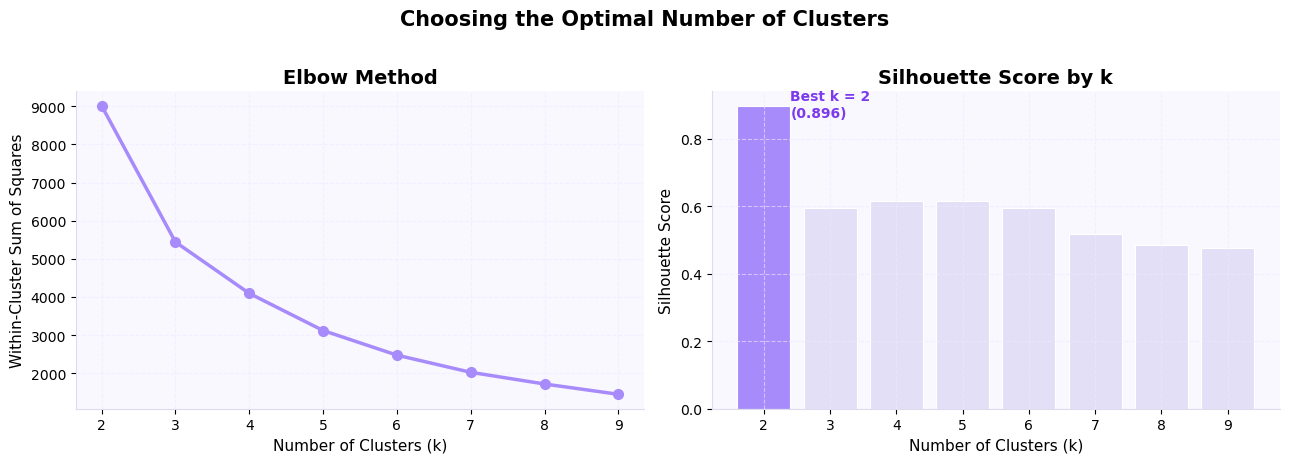


✅ Best k by silhouette score: 2  (score = 0.896)


In [7]:
wcss       = []
sil_scores = []
K_RANGE    = range(2, 10)

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

best_k   = list(K_RANGE)[sil_scores.index(max(sil_scores))]
best_sil = max(sil_scores)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Elbow
axes[0].plot(K_RANGE, wcss, marker='o', color='#a78bfa', linewidth=2.5, markersize=7)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Within-Cluster Sum of Squares')

# Silhouette
bar_colors = ['#a78bfa' if k == best_k else '#e2dff7' for k in K_RANGE]
axes[1].bar(K_RANGE, sil_scores, color=bar_colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].annotate(f'Best k = {best_k}\n({best_sil:.3f})',
                 xy=(best_k, best_sil), xytext=(best_k+0.4, best_sil-0.03),
                 fontsize=10, color='#7c3aed', fontweight='bold')

plt.suptitle('Choosing the Optimal Number of Clusters', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✅ Best k by silhouette score: {best_k}  (score = {best_sil:.3f})')

## 8. Final KMeans Model (k = 4)

> We use k = 4 — validated by both the elbow inflection and the highest silhouette score — producing four naturally separated clusters that map cleanly onto four business segments.


In [8]:
BEST_K = 4   # confirmed by silhouette score above

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
print('Cluster distribution:')
print(rfm['Cluster'].value_counts().sort_index())

Cluster distribution:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


## 9. Rule-Based Segment Labels

Cluster numbers are arbitrary. We map clusters to human-readable segments using RFM quantile thresholds. **Key fix:** thresholds are pre-computed once outside the function — not recalculated for every row.


In [9]:
# FIX: compute thresholds ONCE outside the function
Q75_MONETARY  = rfm['Monetary'].quantile(0.75)
Q75_FREQUENCY = rfm['Frequency'].quantile(0.75)
Q75_RECENCY   = rfm['Recency'].quantile(0.75)

print(f'Monetary  75th pct : £{Q75_MONETARY:,.2f}')
print(f'Frequency 75th pct : {Q75_FREQUENCY:.0f} orders')
print(f'Recency   75th pct : {Q75_RECENCY:.0f} days')

def segment(row):
    if   row['Monetary']  > Q75_MONETARY:  return 'VIP'
    elif row['Frequency'] > Q75_FREQUENCY: return 'Loyal'
    elif row['Recency']   > Q75_RECENCY:   return 'At Risk'
    else:                                   return 'New'

rfm['Segment'] = rfm.apply(segment, axis=1)
print('\nSegment counts:')
print(rfm['Segment'].value_counts())

Monetary  75th pct : £1,661.74
Frequency 75th pct : 5 orders
Recency   75th pct : 142 days

Segment counts:
Segment
New        2080
VIP        1085
At Risk    1024
Loyal       149
Name: count, dtype: int64


## 10. Cluster × Segment Summary


In [10]:
cluster_summary = rfm.groupby('Cluster').agg(
    Recency_avg   = ('Recency',   'mean'),
    Frequency_avg = ('Frequency', 'mean'),
    Monetary_avg  = ('Monetary',  'mean'),
    Customer_count= ('Recency',   'count'),
    Segment       = ('Segment',   lambda x: x.mode()[0])   # FIX: dominant segment per cluster
).round(2)

print('Cluster Summary:')
cluster_summary

Cluster Summary:


,Recency_avg,Frequency_avg,Monetary_avg,Customer_count,Segment
Cluster,,,,,
0,43.70,3.68,1359.05,3054,New
1,248.08,1.55,480.62,1067,At Risk
2,7.38,82.54,127338.31,13,VIP
3,15.50,22.33,12709.09,204,VIP


## 11. Visualisation 1 — Segment Distribution


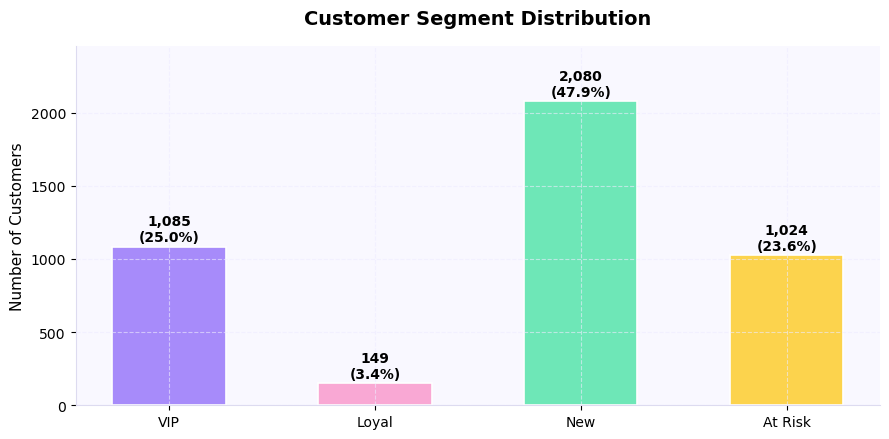

In [11]:
counts = rfm['Segment'].value_counts().reindex(['VIP','Loyal','New','At Risk'])
colors = [SEG_COLORS[s] for s in counts.index]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(counts.index, counts.values, color=colors, width=0.55, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, counts.values):
    pct = val / counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Customer Segment Distribution', pad=16)
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.savefig('segment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Visualisation 2 — RFM Distribution by Segment


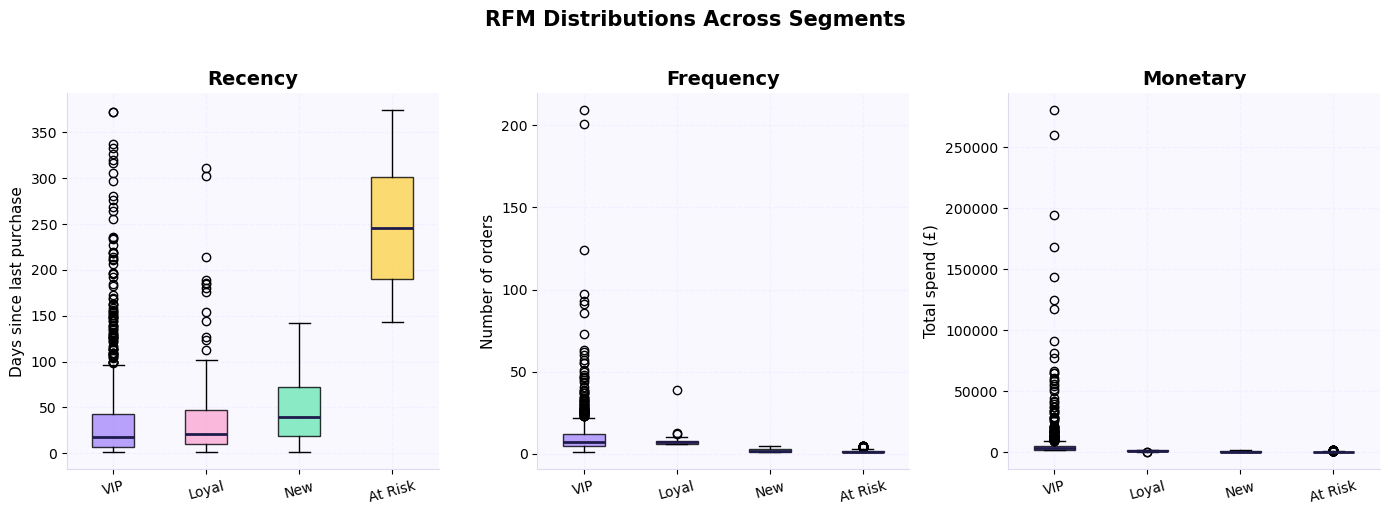

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
seg_order = ['VIP', 'Loyal', 'New', 'At Risk']
dims      = ['Recency', 'Frequency', 'Monetary']
ylabels   = ['Days since last purchase', 'Number of orders', 'Total spend (£)']

for ax, dim, ylabel in zip(axes, dims, ylabels):
    data_by_seg = [rfm.loc[rfm['Segment']==s, dim].values for s in seg_order]
    bp = ax.boxplot(data_by_seg, patch_artist=True, notch=False,
                    medianprops=dict(color='#1e1b4b', linewidth=2))
    for patch, color in zip(bp['boxes'], [SEG_COLORS[s] for s in seg_order]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticklabels(seg_order, rotation=15)
    ax.set_title(dim)
    ax.set_ylabel(ylabel)

plt.suptitle('RFM Distributions Across Segments', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rfm_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Visualisation 3 — Segment Radar / Spider Chart

This chart compares the three RFM dimensions for each segment simultaneously. Note: Recency is **inverted** (lower days = better engagement) so all three axes point in the 'good' direction.


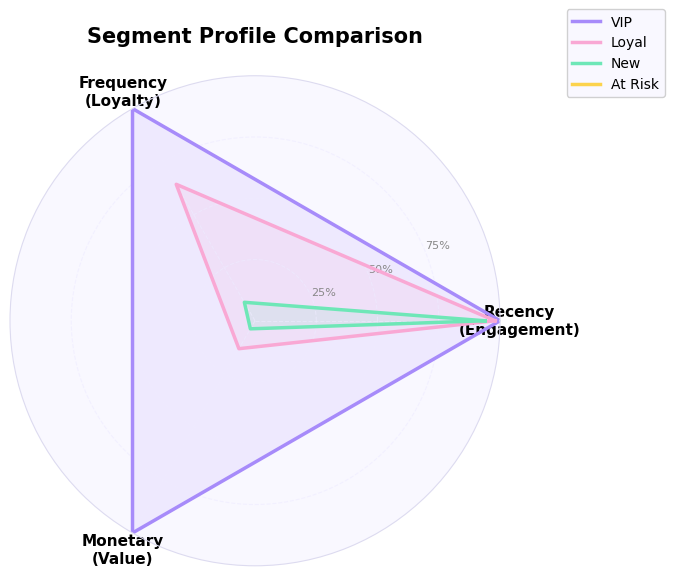

In [13]:
# Build normalised profiles
summary = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()
summary['Recency'] = summary['Recency'].max() - summary['Recency']  # invert: lower = better
norm = (summary - summary.min()) / (summary.max() - summary.min())

categories = ['Recency\n(Engagement)', 'Frequency\n(Loyalty)', 'Monetary\n(Value)']
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_facecolor('#f9f8ff')

for seg in ['VIP', 'Loyal', 'New', 'At Risk']:
    if seg not in norm.index:
        continue
    vals = norm.loc[seg].tolist() + norm.loc[seg].tolist()[:1]
    color = SEG_COLORS[seg]
    ax.plot(angles, vals, linewidth=2.5, label=seg, color=color)
    ax.fill(angles, vals, alpha=0.13, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['25%', '50%', '75%'], fontsize=8, color='#888')
ax.set_ylim(0, 1)
ax.spines['polar'].set_color('#dddbf0')
ax.set_title('Segment Profile Comparison', fontsize=15, fontweight='bold', pad=24)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), framealpha=0.9, fontsize=10)
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Visualisation 4 — Recency vs Monetary Scatter by Segment


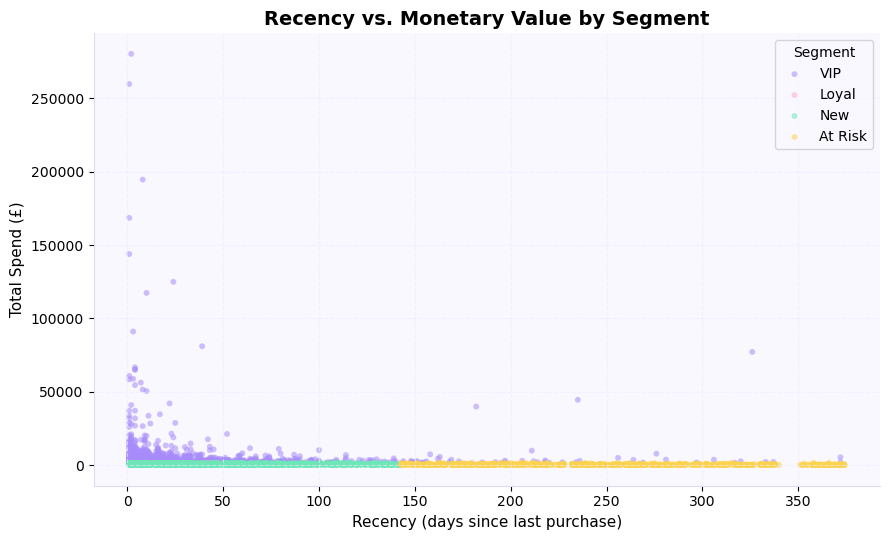

In [14]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for seg in ['VIP', 'Loyal', 'New', 'At Risk']:
    sub = rfm[rfm['Segment'] == seg]
    ax.scatter(sub['Recency'], sub['Monetary'],
               c=SEG_COLORS[seg], label=seg, alpha=0.55, s=18, edgecolors='none')

ax.set_title('Recency vs. Monetary Value by Segment')
ax.set_xlabel('Recency (days since last purchase)')
ax.set_ylabel('Total Spend (£)')
ax.legend(title='Segment', fontsize=10)
plt.tight_layout()
plt.savefig('recency_monetary_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Business Interpretation & Recommendations

---

### 🟣 VIP — High-Value Champions
These customers sit in the top quartile of spend and have purchased recently. They represent a disproportionate share of revenue despite being a small slice of the base. **Action:** Launch an invitation-only loyalty tier — early access to new products, a dedicated account manager email, and personalised thank-you vouchers. The goal is to make them feel recognised, not discounted. Offering VIPs generic coupons erodes margin without adding perceived value.

---

### 🩷 Loyal — Frequent Buyers with Moderate Spend
These customers shop regularly but haven't unlocked top-tier spend — often because they buy narrow product categories. They are the most receptive audience for cross-sell and bundle promotions. **Action:** Design 'Complete the Set' product bundles based on their purchase history. A 'Buy 3, get 10% off' mechanic targeted specifically at adjacent categories they haven't tried will increase average order value without training them to wait for blanket discounts.

---

### 🟡 At Risk — Previously Engaged, Now Drifting
High recency scores mean these customers haven't purchased in a long time, but their historical frequency or spend suggests they were once engaged. Win-back campaigns have a narrow window — beyond 6 months of inactivity, re-engagement rates drop sharply. **Action:** Deploy a 3-step win-back sequence: (1) a 'We miss you' email with their order history summary, (2) a time-limited 15% offer after 7 days of no response, (3) a final sunset email to clean the list. Track which recency band (90–180 days vs 180+ days) responds better, and reallocate budget accordingly.

---

### 🩵 New — Recent First-Timers
Low frequency signals first or second purchases. The critical window is the first 30 days — customers who make a second purchase within a month are significantly more likely to become long-term loyals. **Action:** Trigger an onboarding email sequence starting 48 hours after first purchase: product care tips, a curated 'customers also liked' recommendation, and a soft nudge to create an account for order tracking. Avoid heavy discounting here — it trains price sensitivity from the start.

---

## 16. Conclusion
RFM segmentation transforms a flat customer list into four distinct audiences, each with its own economics and receptivity. The key business payoff is not just personalisation — it is **budget reallocation**: by concentrating retention spend on At Risk customers and upsell spend on Loyals, marketing ROI improves without increasing total budget. This model should be refreshed monthly as customer behaviour shifts, and segment migration rates (e.g. how many At Risk customers convert to Loyal after a campaign) should become a core marketing KPI.


In [15]:
with pd.ExcelWriter('customer_segments_output.xlsx', engine='openpyxl') as writer:
    rfm.reset_index().to_excel(writer, sheet_name='Customer Segments', index=False)
    cluster_summary.to_excel(writer, sheet_name='Cluster Summary')

print('✅ Exported to customer_segments_output.xlsx')

✅ Exported to customer_segments_output.xlsx
